# Gridded CF NetCDF files

CF-convention rectilinear grids. For each file we open it, inspect dimensions/variables/attributes, plot a variable, retrieve the array, reduce a dimension, add and remove a variable, crop every variable with a single polygon, and save the result.

In [1]:
%matplotlib inline
from pathlib import Path
import tempfile

import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon

from pyramids.netcdf import NetCDF, UgridDataset
from pyramids.feature import FeatureCollection

DATA = Path('../../../../examples/data/netcdf/samples')

2026-06-18 16:07:41 | INFO | pyramids.base.config | Logging is configured.


## `cf__7v__1d3-2d3-3d1.nc`

Sea-surface temperature on a global CF grid with **non-square cells** (2° longitude, 1° latitude). Exercises the full workflow — inspect, plot, retrieve, reduce, mutate, wrap longitude, and crop with a polygon — on a grid whose lon and lat spacings differ.

**Open the file and inspect the container**

In [2]:
nc = NetCDF.read_file(DATA / 'cf__7v__1d3-2d3-3d1.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__7v__1d3-2d3-3d1.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [3]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (4):
    bnds                 size=2
    lat                  size=170
    lon                  size=180
    time                 size=24
  Variables (7):
    lat dims=('/lat',) shape=(170,) dtype=float64 unit='degrees_north'
    lat_bnds dims=('/lat', '/bnds') shape=(170, 2) dtype=float64
    lon dims=('/lon',) shape=(180,) dtype=float64 unit='degrees_east'
    lon_bnds dims=('/lon', '/bnds') shape=(180, 2) dtype=float64
    time dims=('/time',) shape=(24,) dtype=float64 unit='days since 2001-1-1'
    time_bnds dims=('/time', '/bnds') shape=(24, 2) dtype=float64
    tos dims=('/time', '/lat', '/lon') shape=(24, 170, 180) dtype=float32 unit='K'
  Global attributes: title, institution, source, contact, project_id, ... (13 total)


**Global attributes**

In [4]:
nc.global_attributes

{'title': 'IPSL  model output prepared for IPCC Fourth Assessment SRES A2 experiment',
 'institution': 'IPSL (Institut Pierre Simon Laplace, Paris, France)',
 'source': 'IPSL-CM4_v1 (2003) : atmosphere : LMDZ (IPSL-CM4_IPCC, 96x71x19) ; ocean ORCA2 (ipsl_cm4_v1_8, 2x2L31); sea ice LIM (ipsl_cm4_v',
 'contact': 'Sebastien Denvil, sebastien.denvil@ipsl.jussieu.fr',
 'project_id': 'IPCC Fourth Assessment',
 'table_id': 'Table O1 (13 November 2004)',
 'experiment_id': 'SRES A2 experiment',
 'realization': 1,
 'cmor_version': 0.9599999785423279,
 'Conventions': 'CF-1.0',
 'history': 'YYYY/MM/JJ: data generated; YYYY/MM/JJ+1 data transformed  At 16:37:23 on 01/11/2005, CMOR rewrote data to comply with CF standards and IPCC Fourth Assessment requirements',
 'references': 'Dufresne et al, Journal of Climate, 2015, vol XX, p 136',
 'comment': 'Test drive'}

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

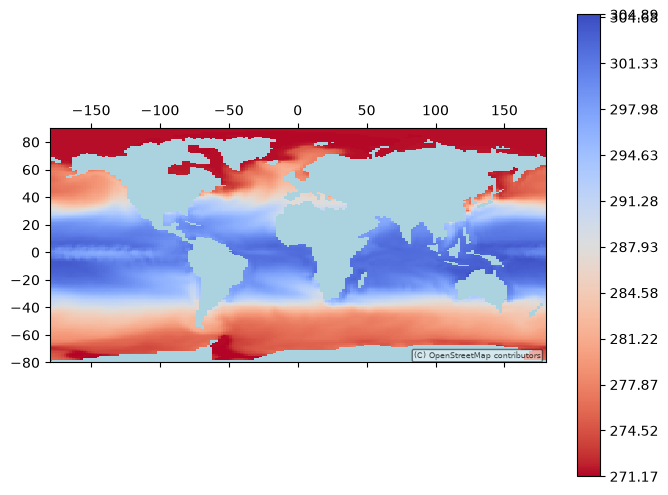

In [5]:
nc.get_variable('tos').wrap_longitude().to_crs(3857).plot(basemap=True)

**Wrap longitude to −180–180** — this grid spans 0–360 (Pacific-centred). `wrap_longitude` re-frames it to the −180–180 (Greenwich-centred) convention; we wrap the selected variable, then plot the re-centred map.

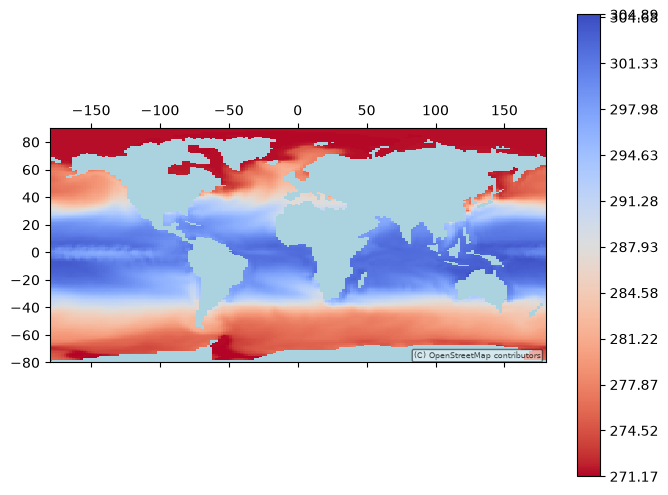

In [6]:
nc.get_variable('tos').wrap_longitude().to_crs(3857).plot(basemap=True)

**Retrieve the underlying data**

In [7]:
var = nc.get_variable('tos')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (24, 170, 180)
min / mean / max: 271.1708679199219 3.1078435030902505e+19 1.0000000200408773e+20


**Reduce a dimension** — collapse the time axis to its mean

In [8]:
time_mean = nc.reduce('time', how='mean')
print('dimensions after reducing time:', dict(time_mean.dimension_sizes))

dimensions after reducing time: {'bnds': 2, 'lat': 170, 'lon': 180, 'x': 180, 'y': 170}


C:\Users\main\AppData\Local\Temp\ipykernel_43992\942131265.py:1: UserWarning: reduce() dropped auxiliary variable(s) ['time_bnds'] that span the reduced dimension 'time'; carrying them unchanged would leave an inconsistent 'time' length in the result.
  time_mean = nc.reduce('time', how='mean')


**Add a variable** — derive a 2-D field and append it as a new variable

In [9]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='tos_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'tos_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['lat_bnds', 'lon_bnds', 'time_bnds', 'tos', 'tos_slice0']


**Remove a variable**

In [10]:
nc.remove_variable('tos_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['lat_bnds', 'lon_bnds', 'time_bnds', 'tos']


**Crop with a real-world polygon** — because `tos` is *sea-surface* temperature, we crop to a recognisable body of water: the **Gulf of Mexico and Caribbean Sea**. Web Mercator basemaps span −180…180 while this grid is 0–360, so we `wrap_longitude()` the variable to −180…180 and reproject it to Web Mercator (EPSG:3857) — then it lines up with the **OpenStreetMap basemap** (`basemap=True`, fetched over the network). The crop keeps this grid's non-square **2°×1°** cells.

2026-06-18 16:07:43 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


cropped tos bounds: [np.float64(-98.0), np.float64(8.0), np.float64(-60.0), np.float64(30.0)]


cell sizes (x, y): 2.0 -1.0


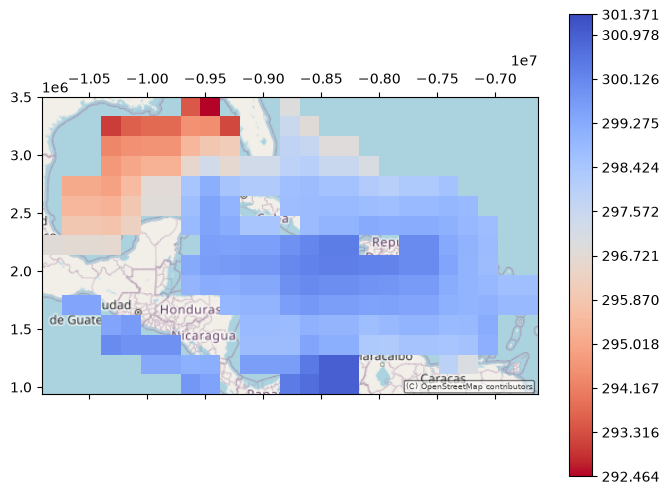

In [11]:
# Gulf of Mexico + Caribbean Sea, in -180..180 longitudes
region = [
    (-98, 18), (-93, 30), (-80, 31), (-75, 27), (-63, 22),
    (-60, 16), (-65, 10), (-75, 9), (-84, 8), (-92, 11), (-98, 18),
]
aoi = FeatureCollection(gpd.GeoDataFrame(geometry=[Polygon(region)], crs=4326))

# this grid is 0-360, but the basemap spans -180..180, so wrap the variable before cropping
tos_gulf = nc.get_variable('tos').wrap_longitude().crop(aoi)
print('cropped tos bounds:', [round(b, 1) for b in tos_gulf.total_bounds])
print('cell sizes (x, y):', tos_gulf.geotransform[1], tos_gulf.geotransform[5])
tos_gulf.to_crs(3857).plot(basemap=True)

**Crop the whole container** — `nc.crop` clips **every** variable in one call and returns a new `NetCDF`. This runs in the file's native 0–360 longitudes (the polygon is shifted back by +360); we then show one cropped variable over an OpenStreetMap basemap (reprojected to Web Mercator / EPSG:3857).

2026-06-18 16:07:44 | WARNING | pyramids.base.config.gdal | GDAL[1] the input vector layer has a SRS, but the source raster dataset does not.
Cutline results may be incorrect.


variables in cropped container: ['lat_bnds', 'lon_bnds', 'time_bnds', 'tos']


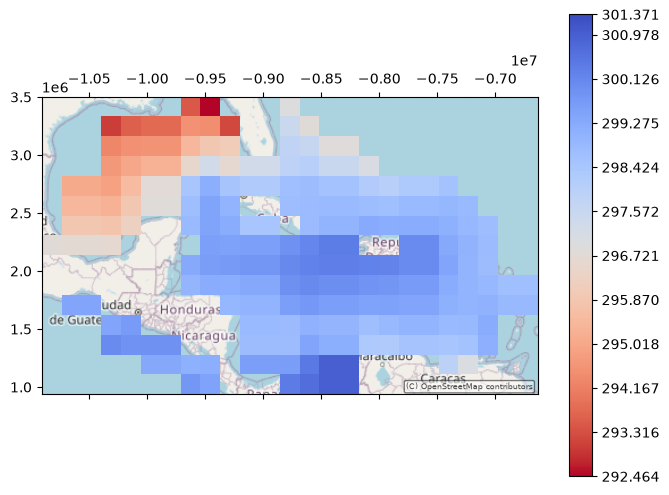

In [12]:
# the whole-container crop runs in the file's native 0-360 longitudes
aoi_native = FeatureCollection(gpd.GeoDataFrame(
    geometry=[Polygon([(x + 360 if x < 0 else x, y) for x, y in region])], crs=4326))
cropped = nc.crop(aoi_native)
print('variables in cropped container:', cropped.variable_names)
tos_gulf.to_crs(3857).plot(basemap=True)

**Save the result to a new NetCDF file**

In [13]:
out = work / 'cropped.nc'
cropped.to_file(str(out))
print('saved cropped container to', out.name, '->', out.exists())

saved cropped container to cropped.nc -> True


## `cf__12v__1d4-2d5-3d2-4d1.nc`

Multi-variable CF file with a 4-D variable (time, level, lat, lon) plus bounds. Its latitudes are Gaussian, so it is not affine-croppable.

**Open the file and inspect the container**

In [14]:
nc = NetCDF.read_file(DATA / 'cf__12v__1d4-2d5-3d2-4d1.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__12v__1d4-2d5-3d2-4d1.nc
       ..\..\..\..\examples\data\netcdf\samples\cf__12v__1d4-2d5-3d2-4d1.nc.aux.xml
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [15]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

2026-06-18 16:07:45 | WARNING | pyramids.base.config.gdal | GDAL[1] Cannot find variable corresponding to coordinate height


NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (5):
    bnds                 size=2
    lat                  size=128
    lon                  size=256
    plev                 size=17
    time                 size=1
  Variables (12):
    area dims=('/lat', '/lon') shape=(128, 256) dtype=float32 unit='meter2'
    lat dims=('/lat',) shape=(128,) dtype=float32 unit='degrees_north'
    lat_bnds dims=('/lat', '/bnds') shape=(128, 2) dtype=float64
    lon dims=('/lon',) shape=(256,) dtype=float32 unit='degrees_east'
    lon_bnds dims=('/lon', '/bnds') shape=(256, 2) dtype=float64
    msk_rgn dims=('/lat', '/lon') shape=(128, 256) dtype=int32 unit='bool'
    plev dims=('/plev',) shape=(17,) dtype=float64 unit='Pa'
    pr dims=('/time', '/lat', '/lon') shape=(1, 128, 256) dtype=float32 unit='kg m-2 s-1'
    tas dims=('/time', '/lat', '/lon') shape=(1, 128, 256) dtype=float32 unit='K'
    time dims=('/time',) shape=(1,) dtype=float64 unit='days since 0000-1-1'
    ... and 2 more


**Global attributes**

In [16]:
nc.global_attributes

{'CVS_Id': '$Id$',
 'creation_date': '',
 'prg_ID': 'Source file unknown Version unknown Date unknown',
 'cmd_ln': 'bds -x 256 -y 128 -m 23 -o /data/zender/data/dst_T85.nc',
 'history': 'Tue Oct 25 15:08:51 2005: ncks -O -x -v va -m sresa1b_ncar_ccsm3_0_run1_200001.nc sresa1b_ncar_ccsm3_0_run1_200001.nc\nTue Oct 25 15:07:21 2005: ncks -d time,0 sresa1b_ncar_ccsm3_0_run1_200001_201912.nc sresa1b_ncar_ccsm3_0_run1_200001.nc\nTue Oct 25 13:29:43 2005: ncks -d time,0,239 sresa1b_ncar_ccsm3_0_run1_200001_209912.nc /var/www/html/tmp/sresa1b_ncar_ccsm3_0_run1_200001_201912.nc\nThu Oct 20 10:47:50 2005: ncks -A -v va /data/brownmc/sresa1b/atm/mo/va/ncar_ccsm3_0/run1/sresa1b_ncar_ccsm3_0_run1_va_200001_209912.nc /data/brownmc/sresa1b/atm/mo/tas/ncar_ccsm3_0/run1/sresa1b_ncar_ccsm3_0_run1_200001_209912.nc\nWed Oct 19 14:55:04 2005: ncks -F -d time,01,1200 /data/brownmc/sresa1b/atm/mo/va/ncar_ccsm3_0/run1/sresa1b_ncar_ccsm3_0_run1_va_200001_209912.nc /data/brownmc/sresa1b/atm/mo/va/ncar_ccsm3_0/r

**Plot the variable** (a 2-D slice is auto-selected for >2-D variables)

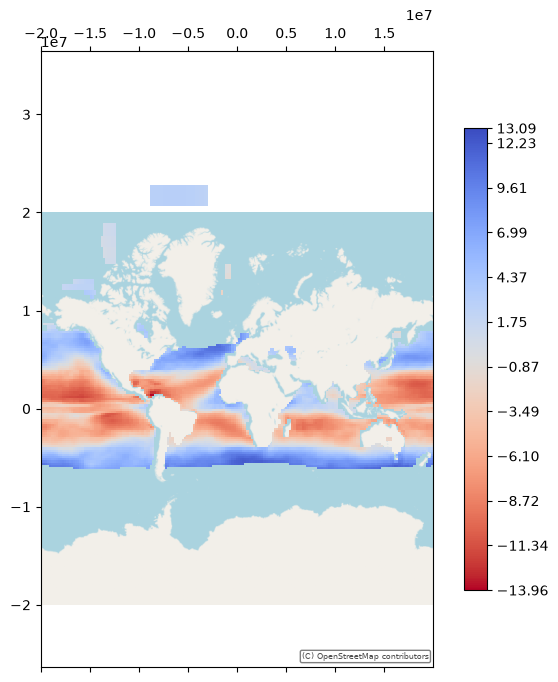

In [17]:
nc.get_variable('ua').wrap_longitude().to_crs(3857).plot(basemap=True)

**Retrieve the underlying data**

In [18]:
var = nc.get_variable('ua')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (17, 128, 256)
min / mean / max: -24.159502029418945 5.543607884874514e+18 1.0000000200408773e+20


**Add a variable** — derive a 2-D field and append it as a new variable

In [19]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='ua_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'ua_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['area', 'lat_bnds', 'lon_bnds', 'msk_rgn', 'pr', 'tas', 'time_bnds', 'ua', 'ua_slice0']


**Remove a variable**

In [20]:
nc.remove_variable('ua_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['area', 'lat_bnds', 'lon_bnds', 'msk_rgn', 'pr', 'tas', 'time_bnds', 'ua']


> **Note** — this file has heterogeneous variable dimensions and a non-affine grid (Gaussian/spectral latitudes, so no single affine geotransform). Container-wide operations — `reduce` across one shared dimension and polygon `crop` (an affine warp) — do not apply uniformly here, so we focus on per-variable inspection, plotting, retrieval, and mutation, then save the container.

**Save the container to a new NetCDF file**

In [21]:
out = work / 'saved.nc'
nc.to_file(str(out))
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True


## `cf__48v__1d17-3d21-4d10.nc`

Large multi-variable CF file mixing 3-D and 4-D fields and string variables on a spectral (CAM) grid. `T` is stored as `(time, lat, lev, lon)` — lat/lon are not the trailing dims — so it needs explicit `x_dim`/`y_dim`; it is also not affine-croppable.

**Open the file and inspect the container**

In [22]:
nc = NetCDF.read_file(DATA / 'cf__48v__1d17-3d21-4d10.nc')
nc

Driver: netCDF/Network Common Data Format
Files: ..\..\..\..\examples\data\netcdf\samples\cf__48v__1d17-3d21-4d10.nc
Size is 512, 512
Corner Coordinates:
Upper Left  (    0.0,    0.0)
Lower Left  (    0.0,  512.0)
Upper Right (  512.0,    0.0)
Lower Right (  512.0,  512.0)
Center      (  256.0,  256.0)

**Dimensions and variables**

In [23]:
# get_all_metadata() returns a NetCDFMetadata whose summary lists dimensions and, for each
# variable, its dims / shape / dtype / unit / scale-offset.
meta = nc.get_all_metadata()
print(meta)

NetCDFMetadata
  Driver: netCDF
  Root group: /
  Dimensions (5):
    ilev                 size=7
    lat                  size=64
    lev                  size=6
    lon                  size=128
    time                 size=1
  Variables (48):
    CLDICE dims=('/time', '/lat', '/lev', '/lon') shape=(1, 64, 6, 128) dtype=float64 unit='kg/kg'
    CLDLIQ dims=('/time', '/lat', '/lev', '/lon') shape=(1, 64, 6, 128) dtype=float64 unit='kg/kg'
    CLOUD dims=('/time', '/lat', '/lev', '/lon') shape=(1, 64, 6, 128) dtype=float64 unit='fraction'
    ICEFRAC dims=('/time', '/lat', '/lon') shape=(1, 64, 128) dtype=float64 unit='fraction'
    LANDFRAC dims=('/time', '/lat', '/lon') shape=(1, 64, 128) dtype=float64 unit='FRAC'
    LANDM dims=('/time', '/lat', '/lon') shape=(1, 64, 128) dtype=float64 unit='none'
    LANDM_COSLAT dims=('/time', '/lat', '/lon') shape=(1, 64, 128) dtype=float64 unit='none'
    LCWAT dims=('/time', '/lat', '/lev', '/lon') shape=(1, 64, 6, 128) dtype=float64
    PBLH 

**Global attributes**

In [24]:
nc.global_attributes

{'Conventions': 'CF-1.0',
 'logname': 'olson',
 'host': 'bb0001en',
 'source': 'Interpolated from:/fs/cgd/data0/olson/inputIC/newICeul.cam2.i.0000-09-01-00000.nc::CAM',
 'case': 'cam2run',
 'title': 'Interpolated from:/fs/cgd/data0/olson/inputIC/newICeul.cam2.i.0000-09-01-00000.nc::atm ver atm, eul ver v013, case newICeul',
 'history': '\n05/07/03 12:15:34 olson:chinookfe:interpic -t SEP1.T42L26.gaussian.template.nc /fs/cgd/data0/olson/inputIC/newICeul.cam2.i.0000-09-01-00000.nc cami_0000-09-01_64x128_L26_c030507.nc\ndefinesurf -t /fs/cgd/csm/inputdata/atm/cam1/hrtopo/topo.nc cami_0000-09-01_64x128_L26_c030507.nc\ndefinesurf -t /fs/cgd/csm/inputdata/atm/cam2/hrtopo/topo.nc cami_0000-09-01_64x128_L26_c030507.nc\ndefinesurf -t /fs/cgd/csm/inputdata/atm/cam2/hrtopo/topo-usgs-10min.nc cami_0000-09-01_64x128_L26_c030507.nc\ndefinesurf -t /fs/cgd/csm/inputdata/atm/cam2/hrtopo/topo10min.merged_c030506.nc cami_0000-09-01_64x128_L26_c030507.nc\ndefinesurf -t /fs/cgd/csm/inputdata/atm/cam2/hrtop

**Plot the variable** — this file stores its dimensions in a non-standard order and its lat/lon coordinates carry no CF axis attributes, so CF auto-detection cannot find the geographic plane. Pass `x_dim`/`y_dim` to select it explicitly (without them, the last two dimensions would be used, giving a level–longitude cross-section).

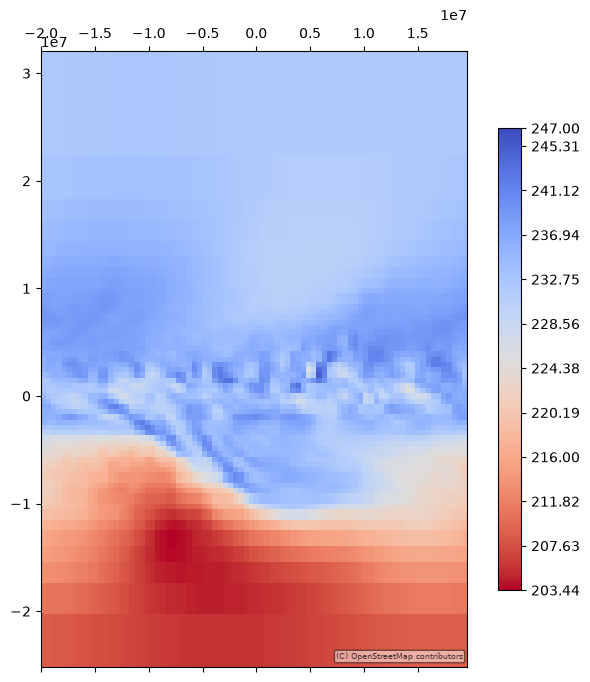

In [25]:
nc.get_variable('T', x_dim='lon', y_dim='lat').wrap_longitude().to_crs(3857).plot(basemap=True)

**Retrieve the underlying data**

In [26]:
var = nc.get_variable('T', x_dim='lon', y_dim='lat')
data = var.read_array()
print('shape:', data.shape)
print('min / mean / max:', float(np.nanmin(data)), float(np.nanmean(data)), float(np.nanmax(data)))

shape: (6, 64, 128)
min / mean / max: 180.13432898897665 221.17292953231126 245.30911131068692


**Add a variable** — derive a 2-D field and append it as a new variable

In [27]:
work = Path(tempfile.mkdtemp())
slice2d = data[tuple(0 for _ in range(data.ndim - 2))]
NetCDF.create_from_array(
    arr=slice2d, geo=var.geotransform, epsg=var.epsg or 4326,
    variable_name='T_slice0', path=str(work / 'derived.nc'),
)
nc.add_variable(NetCDF.read_file(str(work / 'derived.nc')), 'T_slice0')
print('variables after add:', nc.variable_names)

variables after add: ['CLDICE', 'CLDLIQ', 'CLOUD', 'ICEFRAC', 'LANDFRAC', 'LANDM', 'LANDM_COSLAT', 'LCWAT', 'PBLH', 'PHIS', 'PS', 'Q', 'QCWAT', 'QPERT', 'SGH', 'SICTHK', 'SNOWHICE', 'T', 'TBOT', 'TCWAT', 'TPERT', 'TS', 'TS1', 'TS2', 'TS3', 'TS4', 'TSICE', 'TSICERAD', 'TSOCN', 'T_slice0', 'U', 'V', 'date', 'date_written', 'datesec', 'gw', 'hyai', 'hyam', 'hybi', 'hybm', 'ndcur', 'nscur', 'nsteph', 'time_written']


**Remove a variable**

In [28]:
nc.remove_variable('T_slice0')
print('variables after remove:', nc.variable_names)

variables after remove: ['CLDICE', 'CLDLIQ', 'CLOUD', 'ICEFRAC', 'LANDFRAC', 'LANDM', 'LANDM_COSLAT', 'LCWAT', 'PBLH', 'PHIS', 'PS', 'Q', 'QCWAT', 'QPERT', 'SGH', 'SICTHK', 'SNOWHICE', 'T', 'TBOT', 'TCWAT', 'TPERT', 'TS', 'TS1', 'TS2', 'TS3', 'TS4', 'TSICE', 'TSICERAD', 'TSOCN', 'U', 'V', 'date', 'date_written', 'datesec', 'gw', 'hyai', 'hyam', 'hybi', 'hybm', 'ndcur', 'nscur', 'nsteph', 'time_written']


> **Note** — this file has heterogeneous variable dimensions and a non-affine grid (Gaussian/spectral latitudes, so no single affine geotransform). Container-wide operations — `reduce` across one shared dimension and polygon `crop` (an affine warp) — do not apply uniformly here, so we focus on per-variable inspection, plotting, retrieval, and mutation, then save the container.

**Save the container to a new NetCDF file**

In [29]:
out = work / 'saved.nc'
nc.to_file(str(out))
print('saved container to', out.name, '->', out.exists())

saved container to saved.nc -> True
